In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("IRIS.csv")
print("===IRIS Dataset Preview ===")
print(df.head())

===IRIS Dataset Preview ===
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


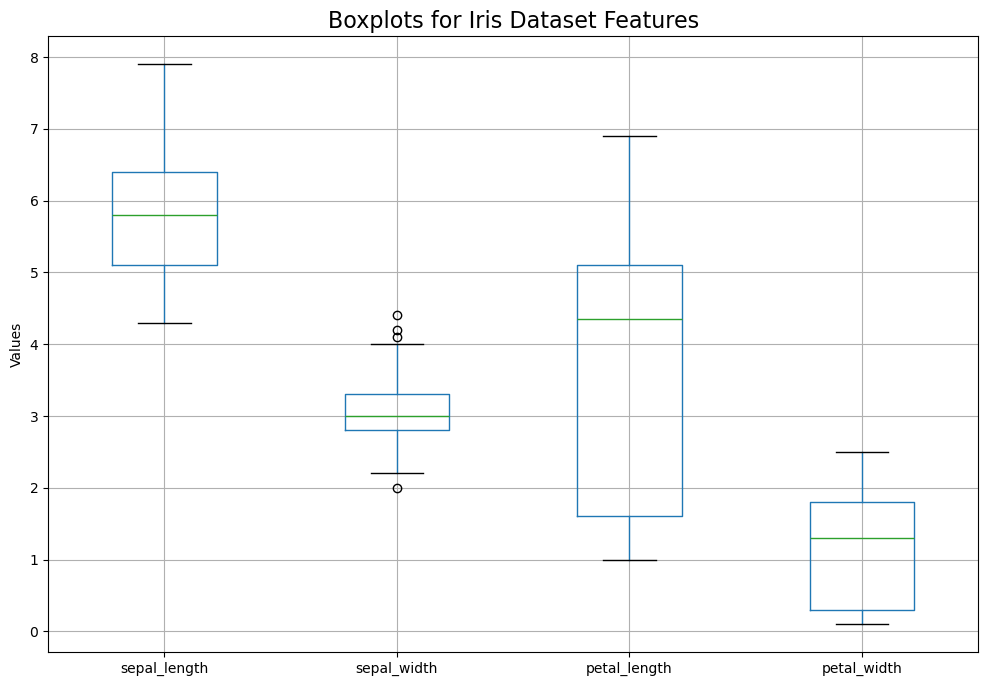

In [7]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(12, 8))
df.boxplot(column=numeric_cols)
plt.title("Boxplots for Iris Dataset Features", fontsize=16)
plt.ylabel("Values")
plt.show()

In [10]:
print("\n=== Outlier Detection using IQR Method ===")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)][col]

    print(f"\nFeature: {col}")
    print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    if outliers.empty:
        print("No outliers found.")
    else:
        print("Outliers:\n", outliers)


=== Outlier Detection using IQR Method ===

Feature: sepal_length
Lower bound: 3.15, Upper bound: 8.35
No outliers found.

Feature: sepal_width
Lower bound: 2.05, Upper bound: 4.05
Outliers:
 15    4.4
32    4.1
33    4.2
60    2.0
Name: sepal_width, dtype: float64

Feature: petal_length
Lower bound: -3.65, Upper bound: 10.35
No outliers found.

Feature: petal_width
Lower bound: -1.95, Upper bound: 4.05
No outliers found.
